In [53]:
import sys
import os

os.chdir("/Users/samstephenson/Downloads/capy-bara")

import pathlib
import capy_core.metrics as metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import gerrychain
from collections import deque
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def colormap(rho, vmin = 0, vmax = 1):
    """
    Builds a diverging colormap and norm centered at rho, running from blue (rho=0) through white (rho=rho) to orange (rho=1).
    Parameters:
        Rho: float
        The rho value at which the colorbar diverges
    """
    if not (vmin < rho < vmax): 
        raise ValueError(f"rho={rho} must be strictly between vmin={vmin} and vmax={vmax}")
    
    diverging_cmap = LinearSegmentedColormap.from_list(
    "rho_diverging",
    ["#2267BC", "#ffffff", "#FFA812"]
    )
    # Norm that maps 0→left, RHO→center (white), 1→right
    norm = TwoSlopeNorm(vmin=vmin, vcenter=rho, vmax=vmax)

    return diverging_cmap, norm

def visualize_iowa(graph, rho):
    """
    Draws the Iowa county adjacency graph with nodes positioned by Mercator-projected lat/lon, colored by each county's local rho value and sized by total population.
    Parameters:
        graph: nx.Graph
            County adjacency graph with node attributes INTPTLON, INTPTLAT, TOTPOP, and x_pop
        rho: float
            The global rho value used to center the diverging colormap
    Returns:
    fig: matplotlib.figure.Figure
        The figure containing the Iowa graph visualization
    ax: matplotlib.axes.Axes
        The axes on which the graph is drawn
    """

    pos = {
    node: (
        float(graph.nodes[node]["INTPTLON"]),
        math.degrees(math.log(math.tan(math.pi/4 + math.radians(float(graph.nodes[node]["INTPTLAT"]))/2)))
    )
    for node in graph.nodes()
    }

    pop = {
        node: graph.nodes[node]["TOTPOP"]
        for node in graph.nodes()
    }

    sizes = [pop[n] / 500 for n in graph.nodes]  # adjust scaling factor
    fig, ax = plt.subplots(figsize=(10, 10))

    node_rhos = [graph.nodes[node]["x_pop"] / graph.nodes[node]["TOTPOP"] for node in graph.nodes()]

    cmap, norm = colormap(rho)
    node_colors = [cmap(norm(r)) for r in node_rhos]

    nx.draw_networkx_nodes(graph, pos=pos, node_size=sizes, node_color=node_colors,
                            edgecolors='black', linewidths=0.5, ax=ax)
    nx.draw_networkx_edges(graph, pos=pos, edge_color="black", width=0.2, alpha=0.5, ax=ax)


    ax.set_aspect('equal')
    ax.axis('off')
    return fig, ax

def populate_cluster_random(start_node, graph, target_x_pop, rng):
    """
    Assigns x_pop via random cluster growth expansion from a seed node until the total x_pop reaches target_x_pop, then sets y_pop as the remainder for every node.
    Parameters:
        start_node: int
            The seed node from which random cluster growth expansion begins
        graph: nx.Graph
            County adjacency graph with node attribute TOTPOP; modified in place
        target_x_pop: float
            The total x_pop at which random cluster growth stops adding nodes to the cluster
        rng: random.Random
            Local RNG instance passed through to each populate_cluster_random call
    Returns:
        graph: nx.Graph
            The modified graph with x_pop and y_pop set on every node
        real_rho: float
            The actual achieved global group fraction, which may exceed the target due to discrete node assignments
    """
    
    queue = deque([start_node])

    visited = set()
    x_pop_sum = 0

    while queue and x_pop_sum < target_x_pop:
        queue = list(queue)
        rng.shuffle(queue)
        queue = deque(queue)
        node = queue.popleft()

        if node in visited or graph.nodes[node]["x_pop"] > 0:
            visited.add(node)
            continue
        visited.add(node)

        # assign values
        graph.nodes[node]["x_pop"] = graph.nodes[node]["TOTPOP"]
        graph.nodes[node]["y_pop"] = 0

        x_pop_sum += graph.nodes[node]["TOTPOP"]

        # add neighbors (randomized expansion)
        neighbors = list(graph.neighbors(node))
        rng.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited:
                queue.append(nbr)


    for node in graph.nodes():
        if graph.nodes[node]["x_pop"] == 0:
            graph.nodes[node]["y_pop"] = graph.nodes[node]["TOTPOP"]

    real_rho = metrics.property_sum(graph, "x_pop")/metrics.property_sum(graph, "TOTPOP")
    
    return graph, real_rho



In [54]:
import scipy.sparse as sp
from scipy.sparse.csgraph import shortest_path

In [55]:
def valid_isolated_config(graph, column):
    """
    Checks whether the x_pop-carrying nodes in the graph form a valid isolated configuration, where every nonzero node is its own connected component (no two selected nodes are adjacent).
    Parameters:
        graph: nx.Graph
            County adjacency graph with node attribute specified by column
        column: str
            Name of the node attribute to check for nonzero values
    Returns:
        bool
            True if the nonzero nodes form a valid isolated configuration, False otherwise
    """

    nodes_in_cluster = []
    
    for node in graph.nodes():
        if graph.nodes[node][column] >0:
            nodes_in_cluster.append(node)
    
    # should have as many connected components as there are nonzero entries
    subgraph = graph.subgraph(nodes_in_cluster)
    return subgraph.number_of_edges() == 0


def make_random_isolated_config(graph, target_rho, rng):
    """
    Randomly assigns x_pop to a greedy independent set of nodes until the global group fraction reaches rho, then sets y_pop as the remainder for every node.
    Parameters:
        graph: nx.Graph
            County adjacency graph with node attribute TOTPOP; modified in place
        rho: float
            Target global group fraction; assignment stops once this value is reached or exceeded
        rng: random.Random
            Local RNG to shuffle node order
    Returns:
        graph: nx.Graph
            The modified graph with x_pop and y_pop set on every node
        real_rho: float
    The actual achieved global group fraction. May exceed target_rho if the last selected node overshoots, or fall short of target_rho if the 
    maximal independent set is exhausted before the target is reached.
    """

    # reset populations
    for node in graph.nodes():
        graph.nodes[node]["x_pop"] = 0
        graph.nodes[node]["y_pop"] = graph.nodes[node]["TOTPOP"]

    blocked = set()

    nodes = list(graph.nodes())
    rng.shuffle(nodes)

    total_pop =  metrics.property_sum(graph, "TOTPOP")
    x_pop = 0
    for node in nodes:
        if node in blocked:
            continue

        blocked.add(node)
        blocked.update(graph.neighbors(node))

        graph.nodes[node]["x_pop"] = graph.nodes[node]["TOTPOP"]
        x_pop+=graph.nodes[node]["x_pop"]
        graph.nodes[node]["y_pop"] = 0

        current_rho = x_pop / total_pop
        if current_rho >= target_rho:
            break

    for node in graph.nodes():
        graph.nodes[node]["y_pop"] = graph.nodes[node]["TOTPOP"] - graph.nodes[node]["x_pop"]

    return graph, metrics.property_sum(graph, "x_pop") / metrics.property_sum(graph, "TOTPOP")

In [56]:
def generate_kclust_grid(graph, target_rho, num_start_nodes, rng):
    """
    Builds a k-cluster configuration by growing num_start_nodes independent random cluster growth clusters, 
    each targeting an equal share of the total x_pop budget, then computes the achieved rho and number of 
    connected components. Clusters from different start nodes can merge into one another but the code only
    returns configurations with at least two unconnected clusters.
    Parameters:
        graph: nx.Graph
            County adjacency graph with node attributes TOTPOP, x_pop, and y_pop; modified in place
        target_rho: float
            Target global group fraction to distribute across num_start_nodes clusters
        num_start_nodes: int
            Number of clusters to grow. Clusters can merge into one another
        rng: random.Random
            Local RNG instance passed through to each populate_cluster_random call
    Returns:
        G: nx.Graph
            The modified graph with x_pop and y_pop set on every node
        real_rho: float
            The actual achieved global group fraction across all clusters
        components: int
            Number of connected components among the x_pop-carrying nodes
    """
    for node in graph.nodes():
        graph.nodes[node]["x_pop"] = 0
        graph.nodes[node]["y_pop"] = 0

    target_pop = target_rho * metrics.property_sum(graph, "TOTPOP") / num_start_nodes

    for _ in range(num_start_nodes):
        y_nodes = [node for node in graph.nodes if graph.nodes[node]["x_pop"] == 0]
        if y_nodes == []:
            return None
        start_node = rng.choice(y_nodes)

        G, cluster_rho = populate_cluster_random(start_node, graph, target_pop, rng)

    for node in G.nodes():
        if G.nodes[node]["x_pop"] == 0:
            G.nodes[node]["y_pop"] = graph.nodes[node]["TOTPOP"]
    
    real_rho = (metrics.property_sum(G, "x_pop") / 
                (metrics.property_sum(G, "x_pop") + 
                metrics.property_sum(G, "y_pop")))
    
    x_nodes = [
        node for node in G.nodes()
        if G.nodes[node]["x_pop"] > 0
        ]

    H = G.subgraph(x_nodes)

    components = nx.number_connected_components(H)

    return G, real_rho, components

In [57]:
def make_random_iowa(graph, rng, target_x_pop):
    for node in graph.nodes():
        graph.nodes[node]["x_pop"] = 0
        graph.nodes[node]["y_pop"] = 0
    nodelist = [node for node in graph.nodes()]
    rng.shuffle(nodelist)
    tot_x_pop = 0
    for node in nodelist:
        if tot_x_pop < target_x_pop:
            graph.nodes[node]["x_pop"] = graph.nodes[node]["TOTPOP"]
            graph.nodes[node]["y_pop"] = 0
            tot_x_pop += graph.nodes[node]["TOTPOP"]
        else:
            break
    for node in nodelist:
        if graph.nodes[node]["x_pop"] == 0:
            graph.nodes[node]["x_pop"] = 0
            graph.nodes[node]["y_pop"] = graph.nodes[node]["TOTPOP"]
    real_rho = (metrics.property_sum(graph, "x_pop") / 
            (metrics.property_sum(graph, "x_pop") + 
            metrics.property_sum(graph, "y_pop")))
    
    return graph, real_rho

In [58]:
import scipy
def moran(graph: gerrychain.Graph, x_col: str, tot_col: str, Weights: scipy.sparse.csr_matrix) -> float:
    """
    Calculates Moran's I for nodes' shares of group x using an arbitrary weights matrix.
    Moran's I is defined by $I(v;W): = \frac{n}{w}(\frac{x^TWx}{x^Tx})$ where W is the weights matrix,
    n is the number of edges, x is a vector containing each node's count of the x population, and 
    $w := \sum_{i,j} \lvert W_{ij} \rvert$.


    Parameters:
        graph: gerrychain.Graph or networkx.Graph
            The graph of interest
        x_col: string
            the column name for population group x
        tot_col: string
            the column name for the total population group
        W: scipy.sparse.csr_matrix
            the weights matrix for the Moran's I calculation

    Returns:
        float:
            the graph's Moran's I for group x.
    """
    try:
        shares = np.array([
            graph.nodes[node][x_col] / graph.nodes[node][tot_col]
            for node in graph.nodes()
            ])
    except ZeroDivisionError:
        raise ValueError("Division by Zero Error: calculating Moran's I requires that all nodes have a non-zero total population.")

    shares -= shares.mean()

    xvec = scipy.sparse.csr_matrix(shares).T

    denominator = (xvec.T @ xvec)[0, 0]
    if denominator == 0:
        raise ZeroDivisionError(
            "Moran's I is undefined when all node shares are identical"
        )

    numerator = (xvec.T @ Weights @ xvec)[0, 0]
    w = abs(Weights).sum()
    moran = (len(graph) / w) * numerator / denominator

    return moran

In [59]:
def get_moran_radius_profile(graph, max_radius, damping_factor, x_col, tot_col, include_self_loops = True):
    """
    """
    morans = []
    if include_self_loops == True:
        for i in range(max_radius):
            adj_matrix = build_higher_order_adj_matrix(graph, i, damping_factor, include_self_loops=include_self_loops) 
            morans.append(moran(graph, x_col, tot_col, adj_matrix))
    else:
        for i in range(max_radius)[1:]:
            adj_matrix = build_higher_order_adj_matrix(graph, i, damping_factor, include_self_loops=include_self_loops) 
            morans.append(moran(graph, x_col, tot_col, adj_matrix))
    return morans


In [60]:
def build_higher_order_adj_matrix(graph, max_adjacency_order, damping_factor, include_self_loops = True):
    """
    """
    csg = nx.to_scipy_sparse_array(graph, format='csr') #changing to csr format to run shortest_path
    dist_matrix = shortest_path(csg, unweighted = True) #nxn array with graph distances in the entries
    size = len(dist_matrix)
    adj_matrix = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if dist_matrix[i, j] == 0:
                continue
            elif dist_matrix[i,j] > max_adjacency_order:
                adj_matrix[i, j] = 0
            else: 
                adj_matrix[i,j] = damping_factor ** (dist_matrix[i,j] -1)
    if include_self_loops == True:
        adj_matrix = adj_matrix + np.eye(size)
    return adj_matrix

In [61]:
g = gerrychain.Graph.from_json("data/experiment_specific/ia_files/ia_counties_2020.json")
rng = random.Random(44)

g_ , real_rho_  = make_random_iowa(g.copy(), rng, 0.3 * metrics.property_sum(g, "TOTPOP"))
g__, real_rho__, components = generate_kclust_grid(g.copy(), 0.3, 3, rng)
g___, real_rho___ = make_random_isolated_config(g.copy(), 0.3, rng)
print(real_rho_, real_rho__, real_rho___)

0.30522488151057137 0.43873232218592895 0.19571309776392637


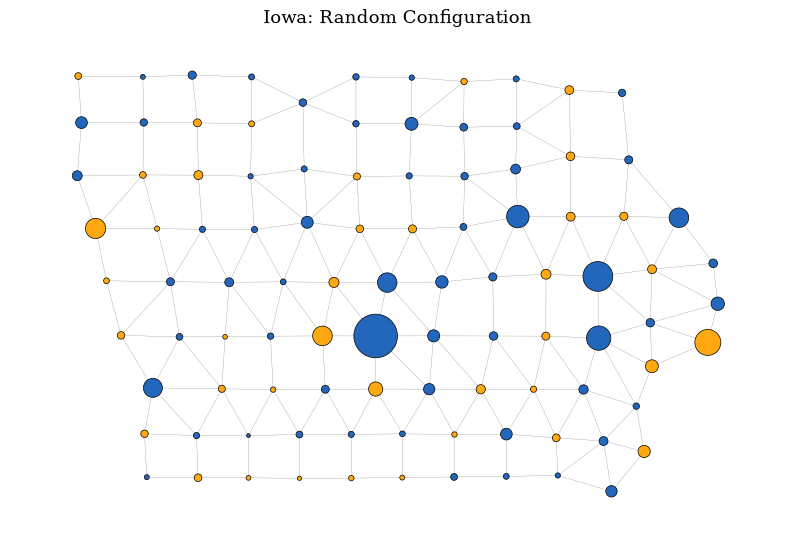

In [ ]:
fig, ax = visualize_iowa(g_, real_rho_)
fig.savefig(f"figures/iowa_prototypes/random_iowa_rho={real_rho_}.png", dpi=300, bbox_inches="tight")

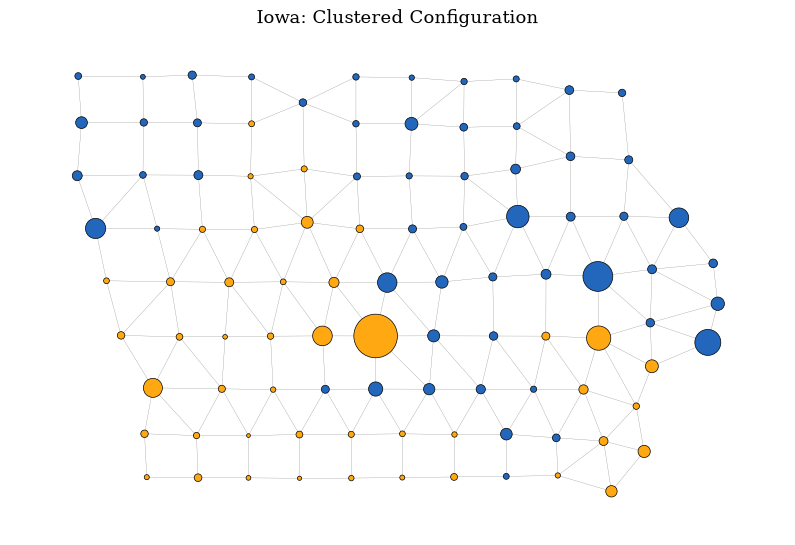

In [ ]:
fig, ax = visualize_iowa(g__, real_rho__)
fig.savefig(f"figures/iowa_prototypes/clustered_iowa_rho={real_rho__}.png", dpi=300, bbox_inches="tight")

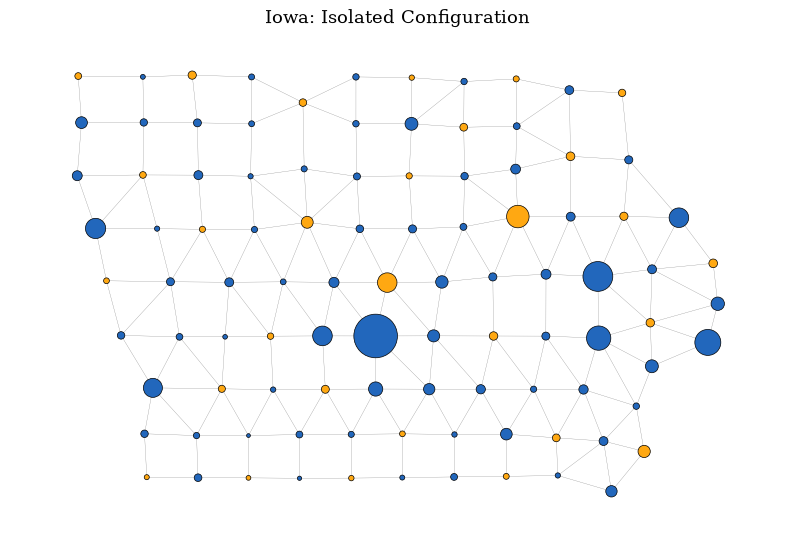

In [ ]:
fig, ax = visualize_iowa(g___, real_rho___)
fig.savefig(f"figures/iowa_prototypes/isol_iowa_rho={real_rho___}.png", dpi=300, bbox_inches="tight")

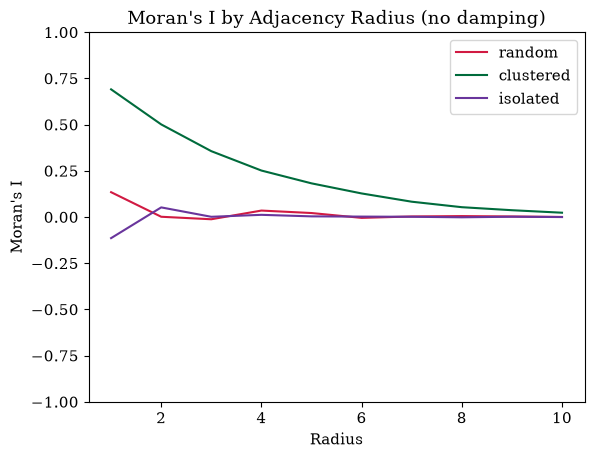

In [65]:
metrics_ = get_moran_radius_profile(g_, 11, 1, "x_pop", "TOTPOP")
metrics__ = get_moran_radius_profile(g__, 11, 1, "x_pop", "TOTPOP")
metrics___ = get_moran_radius_profile(g___, 11, 1, "x_pop", "TOTPOP")

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(11)[1:]
ax.plot(radii, metrics_[1:],   color="#d11a42",   label="random")
ax.plot(radii, metrics__[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, metrics___[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (no damping)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")
fig.savefig("figures/iowa_prototypes/iowa_colored_pointcloud_capy.png", dpi=300, bbox_inches="tight")

Text(0.5, 0, 'Radius')

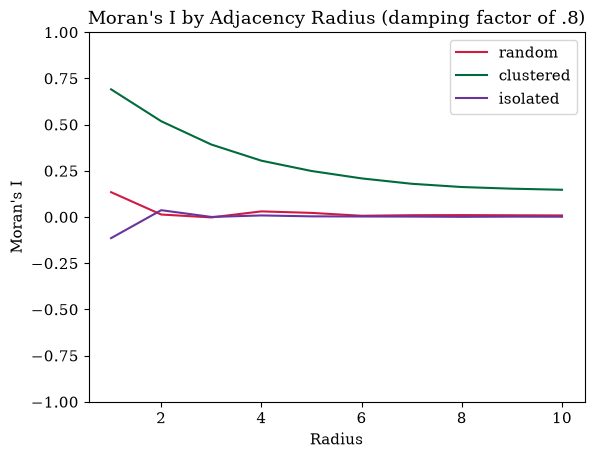

In [66]:
metrics_ = get_moran_radius_profile(g_, 11, 0.8, "x_pop", "TOTPOP")
metrics__ = get_moran_radius_profile(g__, 11, 0.8, "x_pop", "TOTPOP")
metrics___ = get_moran_radius_profile(g___, 11, 0.8, "x_pop", "TOTPOP")

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(11)[1:]
ax.plot(radii, metrics_[1:],   color="#d11a42",   label="random")
ax.plot(radii, metrics__[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, metrics___[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (damping factor of .8)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")

Text(0.5, 0, 'Radius')

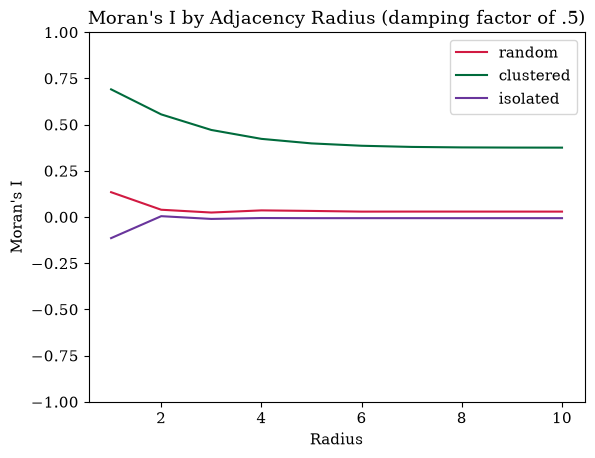

In [67]:
metrics_ = get_moran_radius_profile(g_, 11, 0.5, "x_pop", "TOTPOP")
metrics__ = get_moran_radius_profile(g__, 11, 0.5, "x_pop", "TOTPOP")
metrics___ = get_moran_radius_profile(g___, 11, 0.5, "x_pop", "TOTPOP")

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                    "font.size": 11, "savefig.dpi": 300})

fig, ax = plt.subplots()
radii = range(11)[1:]
ax.plot(radii, metrics_[1:],   color="#d11a42",   label="random")
ax.plot(radii, metrics__[1:],  color="#006B3C",  label="clustered")
ax.plot(radii, metrics___[1:], color="#69359c",   label="isolated")

ax.set_ylim(-1, 1)
ax.legend()
ax.set_title("Moran's I by Adjacency Radius (damping factor of .5)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")

Text(0.5, 0, 'Radius')

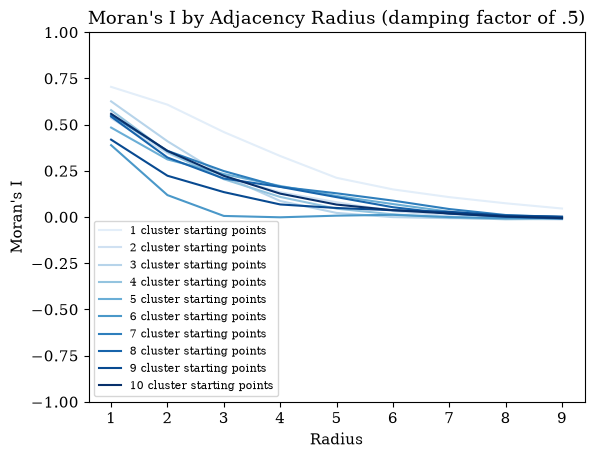

In [68]:
TARGET_RHO = 0.3
max_radius = 10
max_num_clusters = 10
fig, ax = plt.subplots()
radii = range(max_radius)[1:]
graph = gerrychain.Graph.from_json("data/experiment_specific/ia_files/ia_counties_2020.json")
real_rhos = []
for i in range(max_num_clusters + 1)[1:]:
    rng = random.Random(i)
    g, real_rho, components = generate_kclust_grid(graph, TARGET_RHO, i, rng)
    real_rhos.append(real_rho_)
    morans = get_moran_radius_profile(g, max_radius, 1, "x_pop", "TOTPOP")
    ax.plot(radii, morans[1:], color=plt.cm.Blues(i / max_num_clusters)
,   label=f"{i} cluster starting points")
ax.set_ylim(-1, 1)
ax.legend(fontsize=8)
ax.set_title("Moran's I by Adjacency Radius (damping factor of .5)")
ax.set_ylabel("Moran's I")
ax.set_xlabel("Radius")

In [69]:
def blah():
        g_ , real_rho_  = make_random_iowa(g.copy(), rng, rho * metrics.property_sum(g, "TOTPOP"))
        real_rhos_random.append(real_rho_)
        capys_random.append(metrics.half_edge(g_, "y_pop", "x_pop"))
        morans_random.append(metrics.moran(g_, "x_pop", "TOTPOP")["moran_P"])    

        g__, real_rho__, components = generate_kclust_grid(g.copy(), rho, 1, rng)
        real_rhos_clust.append(real_rho__)
        capys_clust.append(metrics.half_edge(g__, "y_pop", "x_pop"))
        morans_clust.append(metrics.moran(g__, "x_pop", "TOTPOP")["moran_P"])   

        g___, real_rho___ = make_random_isolated_config(g.copy(), rho, rng)
        real_rhos_isol.append(real_rho___)
        capys_isol.append(metrics.half_edge(g___, "y_pop", "x_pop"))
        morans_isol.append(metrics.moran(g___, "x_pop", "TOTPOP")["moran_P"])

In [ ]:
import matplotlib.patches as mpatches
import gerrychain

####NEW IOWA
g = gerrychain.Graph.from_json("data/experiment_specific/ia_files/ia_counties_2020.json")
num_rhos = 50
num_samples = 100

real_rhos_isol = []
real_rhos_clust = []
real_rhos_random = []
target_rhos = []
capys_isol = []
morans_isol =[]
capys_clust = []
morans_clust =[]
capys_random = []
morans_random =[]

#generating samples
rho_grid = np.linspace(.001, .5, num_rhos)
nodes = list(g.nodes())
total_pop = metrics.property_sum(g, "TOTPOP")

for i in range(num_samples):
    rng = random.Random(i)
    for rho in rho_grid:
        target_rhos.append(rho)
        start_node = rng.choice(nodes)
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0
        
        g_ , real_rho_  = make_random_iowa(g.copy(), rng, rho * metrics.property_sum(g, "TOTPOP"))
        real_rhos_random.append(real_rho_)
        capys_random.append(metrics.half_edge(g_, "y_pop", "x_pop"))
        morans_random.append(metrics.moran(g_, "x_pop", "TOTPOP")["moran_P"])    

        g__, real_rho__, components = generate_kclust_grid(g.copy(), rho, 1, rng)
        real_rhos_clust.append(real_rho__)
        capys_clust.append(metrics.half_edge(g__, "y_pop", "x_pop"))
        morans_clust.append(metrics.moran(g__, "x_pop", "TOTPOP")["moran_P"])   

        g___, real_rho___ = make_random_isolated_config(g.copy(), rho, rng)
        real_rhos_isol.append(real_rho___)
        capys_isol.append(metrics.half_edge(g___, "y_pop", "x_pop"))
        morans_isol.append(metrics.moran(g___, "x_pop", "TOTPOP")["moran_P"])

NameError: name 'gerrychain' is not defined

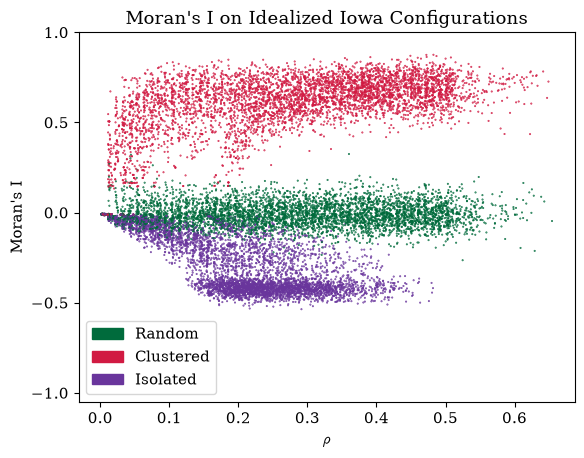

In [76]:
fig, ax = plt.subplots()
#006B3C
all_points = (
    [(x, y, "#006B3C", "random")    for x, y in zip(real_rhos_random, morans_random)] +
    [(x, y, "#d11a42", "clustered") for x, y in zip(real_rhos_clust,  morans_clust)]  +
    [(x, y, "#69359c", "isolated")  for x, y in zip(real_rhos_isol,   morans_isol)]
)

random.shuffle(all_points)
xs, ys, colors, _ = zip(*all_points)
ax.scatter(xs, ys, c=colors, s=0.2)

ax.legend(handles=[
    mpatches.Patch(color="#006B3C", label="Random"),
    mpatches.Patch(color="#d11a42", label="Clustered"),
    mpatches.Patch(color="#69359c", label="Isolated"),
])
ax.set_title("Moran's I on Idealized Iowa Configurations")
ax.set_ylabel("Moran's I")
ax.set_xlabel(r"$\rho$")
ax.set_ylim(-1.05, 1)
ax.set_yticks(np.arange(-1, 1.01, 0.5))

fig.savefig("figures/iowa_prototypes/iowa_colored_pointcloud_moran.png", dpi=300, bbox_inches="tight")

plt.show()

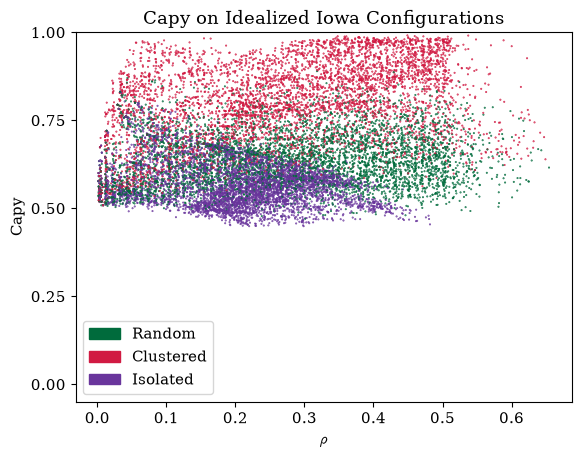

In [77]:
fig, ax = plt.subplots()
#006B3C
all_points = (
    [(x, y, "#006B3C", "random")    for x, y in zip(real_rhos_random, capys_random)] +
    [(x, y, "#d11a42", "clustered") for x, y in zip(real_rhos_clust,  capys_clust)]  +
    [(x, y, "#69359c", "isolated")  for x, y in zip(real_rhos_isol,   capys_isol)]
)
random.shuffle(all_points)
xs, ys, colors, _ = zip(*all_points)
ax.scatter(xs, ys, c=colors, s=0.2)

ax.legend(handles=[
    mpatches.Patch(color="#006B3C", label="Random"),
    mpatches.Patch(color="#d11a42", label="Clustered"),
    mpatches.Patch(color="#69359c", label="Isolated"),
])
ax.set_title("Capy on Idealized Iowa Configurations")
ax.set_ylabel("Capy")
ax.set_xlabel(r"$\rho$")
ax.set_ylim(-0.05, 1)
ax.set_yticks(np.arange(0, 1.01, 0.25))

fig.savefig("figures/iowa_prototypes/iowa_colored_pointcloud_capy.png", dpi=300, bbox_inches="tight")
